## **1. Nombre del Proyecto**

### Predicción temprana de enfermedad cardiaca a partir de variables clínicas

## **2. Comprensión del Negocio**

### **2. 1 Objetivo del negocio :** Disminuir eventos y costos asociados a enfermedad cardiaca detectando tempranamente a pacientes de alto riesgo, para priorizar evaluación clínica y prevención.

### **2. 2 Uso del negocio :**


*   **Triaje clínico:** al registrar signos/hábitos, el sistema devuelve nivel de riesgo (bajo/medio/alto) y acciones sugeridas.
*   **Gestión de casos:** panel para monitorear recall del positivo (pacientes con cardiopatía) y derivar a evaluación.

## **3. Comprensión de los Datos**

### **3. 1 Población objetivo :** Adultos atendidos en servicios de salud con datos clínicos básicos (edad, presión arterial, colesterol, ECG, frecuencia cardiaca, angina de ejercicio y parámetros ST). Se estima en el momento del registro su probabilidad de enfermedad cardiaca.

### **3. 2 Espacio temporal :** Datos transversales (una visita). La predicción se realiza en el momento del registro (no es serie temporal).

### **3. 3 KPI del negocio :**

*   Recall del positivo (HeartDisease=1) como métrica prioritaria (minimizar falsos negativos).
*   Complementarias: F1-macro y ROC-AUC.

### **3. 4 Target :** HeartDisease (0 = no, 1 = sí).

### **3. 5 Fuentes / variables :**

* **Numéricas:** Age, RestingBP (mmHg), Cholesterol (mg/dl), MaxHR, Oldpeak
* **Binaria:** FastingBS (1 si glucemia en ayunas >120 mg/dl)
* **Categóricas:** Sex (M/F), ChestPainType (ATA/NAP/ASY/TA), RestingECG (Normal/ST/LVH), ExerciseAngina (Y/N), ST_Slope (Up/Flat/Down)

## **Diccionario de variables :**

* **Age:** edad (años).
* **Sex:** sexo (M/F).
* **ChestPainType:** tipo de dolor torácico (ATA, NAP, ASY, TA).
* **RestingBP:** PA en reposo (mmHg).
* **Cholesterol:** colesterol sérico (mg/dl).
* **FastingBS:** 1 si glucosa en ayunas >120 mg/dl.
* **RestingECG:** ECG en reposo (Normal/ST/LVH).
* **MaxHR:** FC máxima alcanzada (lpm).
* **ExerciseAngina:** angina inducida por ejercicio (Y/N).
* **Oldpeak:** depresión ST (vs reposo).
* **ST_Slope:** pendiente del segmento ST (Up/Flat/Down).
* **HeartDisease:** target (0/1).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ruta = "/content/drive/MyDrive/PROYECTOS PERSONALES/heart.csv"

##Importación de paquetes y subida del DataFrame

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv(ruta)
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


##Análisis y detección de Outliers

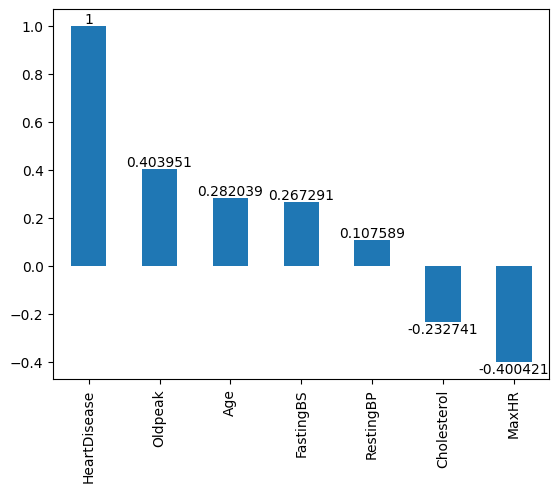

In [ ]:
matriz_corr = data.select_dtypes(["number"]).corr()
ax = matriz_corr["HeartDisease"].sort_values(ascending=False).plot(kind="bar")
for container in ax.containers:
  ax.bar_label(container)
plt.show()

In [ ]:
data._get_numeric_data().corr()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.254399,-0.095282,0.198039,-0.382045,0.258612,0.282039
RestingBP,0.254399,1.000000,0.100893,0.070193,-0.112135,0.164803,0.107589
Cholesterol,-0.095282,0.100893,1.000000,-0.260974,0.235792,0.050148,-0.232741
FastingBS,0.198039,0.070193,-0.260974,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.382045,-0.112135,0.235792,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.258612,0.164803,0.050148,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.282039,0.107589,-0.232741,0.267291,-0.400421,0.403951,1.000000


##Eliminacion automatizada de Outliers con método Clip

In [ ]:
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
data_clean = data.copy()
for col in numeric_cols:
  q1 = data[col].quantile(0.25)
  q3 = data[col].quantile(0.75)
  iqr = q3 - q1
  l_inf = q1 - 1.5*iqr
  l_sup = q3 + 1.5*iqr
  data_clean[col] = data_clean[col].clip(l_inf,l_sup)

In [ ]:
data_clean.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


In [ ]:
data_clean.isna().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


##Revisión del balanceo de la variable Target

In [ ]:
data_clean["HeartDisease"].value_counts()

,count
HeartDisease,
1,508
0,410


In [ ]:
data_clean["HeartDisease"].value_counts(normalize=True)*100

,proportion
HeartDisease,
1,55.337691
0,44.662309


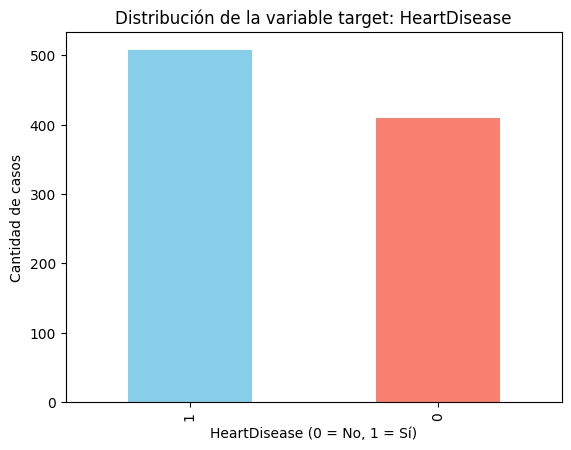

In [ ]:
data['HeartDisease'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribución de la variable target: HeartDisease')
plt.xlabel('HeartDisease (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de casos')
plt.show()


##Análisis exploratorio de datos

<function matplotlib.pyplot.show(close=None, block=None)>

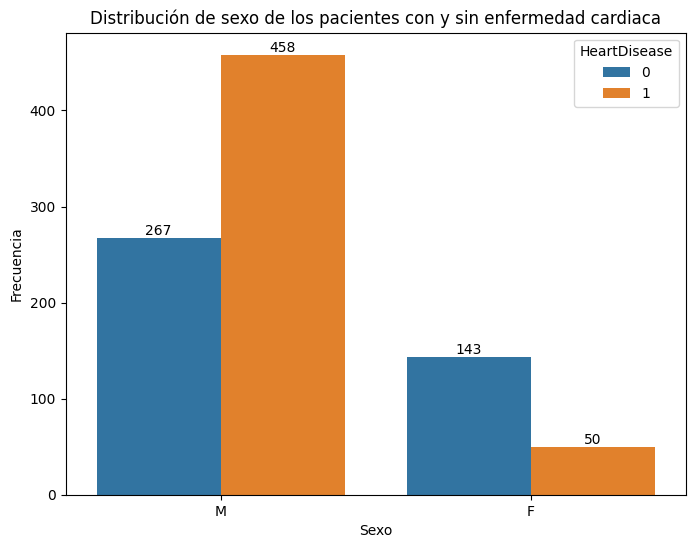

In [ ]:
plt.figure(figsize=(8,6))
ax = sns.countplot(x='Sex',hue='HeartDisease',data=data_clean)
plt.title('Distribución de sexo de los pacientes con y sin enfermedad cardiaca')
plt.xlabel('Sexo')
plt.ylabel('Frecuencia')

for container in ax.containers:
    ax.bar_label(container)
plt.show

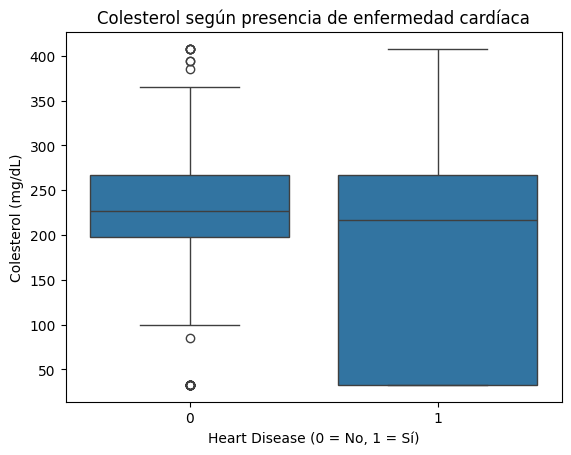

In [ ]:
sns.boxplot(x='HeartDisease', y='Cholesterol', data=data_clean)
plt.title('Colesterol según presencia de enfermedad cardíaca')
plt.xlabel('Heart Disease (0 = No, 1 = Sí)')
plt.ylabel('Colesterol (mg/dL)')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

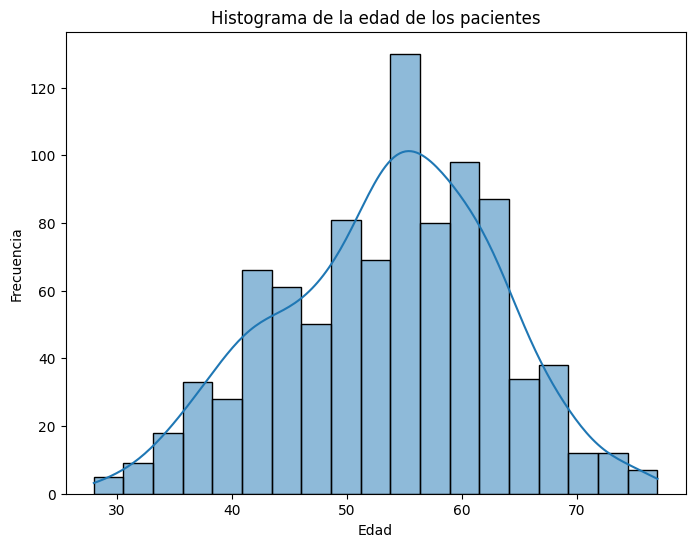

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(data_clean['Age'],kde=True)
plt.title('Histograma de la edad de los pacientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show

##Entrenamiento del modelo

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report,roc_auc_score,roc_curve,auc,RocCurveDisplay
from sklearn.preprocessing import StandardScaler

In [ ]:
X = data_clean.drop("HeartDisease",axis=1)
y = data_clean["HeartDisease"]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [ ]:
columnas_estandarizadas = ["Age","RestingBP","Cholesterol","MaxHR","Oldpeak"]
columnas_nominales = ["Sex","ChestPainType","RestingECG","ExerciseAngina","ST_Slope"]

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train[columnas_estandarizadas])
X_test_scaled = scaler.transform(X_test[columnas_estandarizadas])

In [ ]:
X_train_dummies = pd.get_dummies(X_train[columnas_nominales])
X_test_dummies = pd.get_dummies(X_test[columnas_nominales])

In [ ]:
X_train_dummies, X_test_dummies = X_train_dummies.align(X_test_dummies, join='left', axis=1, fill_value=0)

In [ ]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns = columnas_estandarizadas, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns = columnas_estandarizadas, index=X_test.index)

In [ ]:
X_train_final = pd.concat([X_train_scaled_df, X_train_dummies], axis=1)
X_test_final = pd.concat([X_test_scaled_df, X_test_dummies], axis=1)

In [ ]:
modelo = LogisticRegression()
modelo.fit(X_train_final,y_train)

LogisticRegression()

In [ ]:
y_pred = modelo.predict(X_test_final)

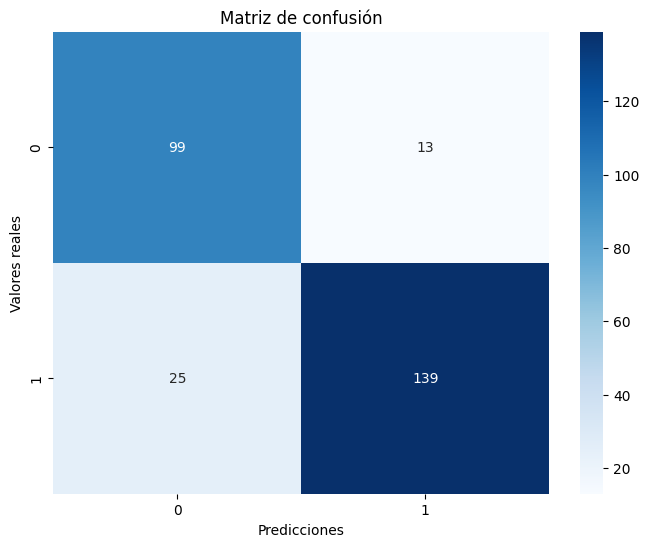

In [ ]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicciones')
plt.ylabel('Valores reales')
plt.title('Matriz de confusión')
plt.show()

In [ ]:
#Obtenemos las probabilidades
y_pred_proba = modelo.predict_proba(X_test_final)[:,1]

#Calcular puntos de la curva
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

#Calcular AUC
auc = roc_auc_score(y_test,y_pred_proba)

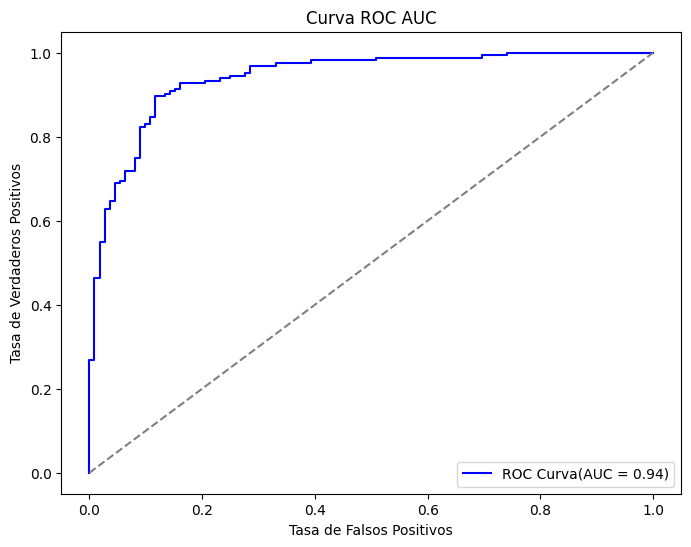

In [ ]:
#Grafico del ROC AUC
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color="blue",label = f'ROC Curva(AUC = {auc:.2f})')
plt.plot([0,1],[0,1],color="gray",linestyle="--")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC AUC")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       112
           1       0.91      0.85      0.88       164

    accuracy                           0.86       276
   macro avg       0.86      0.87      0.86       276
weighted avg       0.87      0.86      0.86       276



In [ ]:
y_pred_train = modelo.predict(X_train_final)

In [ ]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.86      0.83      0.84       298
           1       0.86      0.88      0.87       344

    accuracy                           0.86       642
   macro avg       0.86      0.85      0.86       642
weighted avg       0.86      0.86      0.86       642



Se evidencia que las metricas de entrenamiento y test varían mínimamente. Esto es indicativo de no presencia de overfitting

In [ ]:
from sklearn.model_selection import cross_val_score

cv_auc = cross_val_score(modelo, X_train_final, y_train, cv=5, scoring='roc_auc')
print(f"AUC promedio CV: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")

AUC promedio CV: 0.916 ± 0.014
